# Vehicle Loan Prediction Machine Learning Model
## Load and Clean the Data

In [160]:
## Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [161]:
# load data
loan_df = pd.read_csv('vehicle_loans.csv', index_col='UNIQUEID')

In [162]:
loan_df.head(10)

,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,DATE_OF_BIRTH,EMPLOYMENT_TYPE,DISBURSAL_DATE,...,SEC_SANCTIONED_AMOUNT,SEC_DISBURSED_AMOUNT,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH,NO_OF_INQUIRIES,LOAN_DEFAULT
UNIQUEID,,,,,,,,,,,,,,,,,,,,,
420825,50578,58400,89.55,67,22807,45,1441,01-01-1984,Salaried,03-08-2018,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
537409,47145,65550,73.23,67,22807,45,1502,31-07-1985,Self employed,26-09-2018,...,0,0,1991,0,0,1,1yrs 11mon,1yrs 11mon,0,1
417566,53278,61360,89.63,67,22807,45,1497,24-08-1985,Self employed,01-08-2018,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
624493,57513,66113,88.48,67,22807,45,1501,30-12-1993,Self employed,26-10-2018,...,0,0,31,0,0,0,0yrs 8mon,1yrs 3mon,1,1
539055,52378,60300,88.39,67,22807,45,1495,09-12-1977,Self employed,26-09-2018,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,1,1
518279,54513,61900,89.66,67,22807,45,1501,08-09-1990,Self employed,19-09-2018,...,0,0,1347,0,0,0,1yrs 9mon,2yrs 0mon,0,0
529269,46349,61500,76.42,67,22807,45,1502,01-06-1988,Salaried,23-09-2018,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
510278,43894,61900,71.89,67,22807,45,1501,04-10-1989,Salaried,16-09-2018,...,0,0,0,0,0,0,0yrs 2mon,0yrs 2mon,0,0
490213,53713,61973,89.56,67,22807,45,1497,15-11-1991,Self employed,05-09-2018,...,0,0,0,0,0,0,4yrs 8mon,4yrs 8mon,1,0


In [163]:
loan_df.shape

(233154, 40)

In [164]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 233154 entries, 420825 to 630213
Data columns (total 40 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   DISBURSED_AMOUNT                     233154 non-null  int64  
 1   ASSET_COST                           233154 non-null  int64  
 2   LTV                                  233154 non-null  float64
 3   BRANCH_ID                            233154 non-null  int64  
 4   SUPPLIER_ID                          233154 non-null  int64  
 5   MANUFACTURER_ID                      233154 non-null  int64  
 6   CURRENT_PINCODE_ID                   233154 non-null  int64  
 7   DATE_OF_BIRTH                        233154 non-null  object 
 8   EMPLOYMENT_TYPE                      225493 non-null  object 
 9   DISBURSAL_DATE                       233154 non-null  object 
 10  STATE_ID                             233154 non-null  int64  
 11  EMPLOYEE_CODE

In [165]:
# loan_df['DISBURSAL_DATE'] = pd.to_datetime(loan_df['DISBURSAL_DATE'], infer_datetime_format=True, errors='coerce') - old version to fix date type errors
loan_df['DISBURSAL_DATE'] = pd.to_datetime(loan_df['DISBURSAL_DATE'], format='mixed')



In [166]:
loan_df['DISBURSAL_DATE'].info()

<class 'pandas.core.series.Series'>
Index: 233154 entries, 420825 to 630213
Series name: DISBURSAL_DATE
Non-Null Count   Dtype         
--------------   -----         
233154 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 3.6 MB


In [167]:
print(f"Maximum Disbursal Date: {loan_df['DISBURSAL_DATE'].max()} \n"
      f"Minimum Disbursal Date: {loan_df['DISBURSAL_DATE'].min()} \n"
      f"Timespan of Data Set:   {loan_df['DISBURSAL_DATE'].max() - loan_df['DISBURSAL_DATE'].min()}")

Maximum Disbursal Date: 2018-12-10 00:00:00 
Minimum Disbursal Date: 2018-01-08 00:00:00 
Timespan of Data Set:   336 days 00:00:00


## Target Variable

- Variable we are trying to predict
- LOAN_DEFAULT is our target variable so lets investigate it further

In [168]:
loan_df['LOAN_DEFAULT'].value_counts()

LOAN_DEFAULT
0    182543
1     50611
Name: count, dtype: int64

In [169]:
# target normalized
loan_df['LOAN_DEFAULT'].value_counts(normalize=True)

LOAN_DEFAULT
0    0.782929
1    0.217071
Name: proportion, dtype: float64

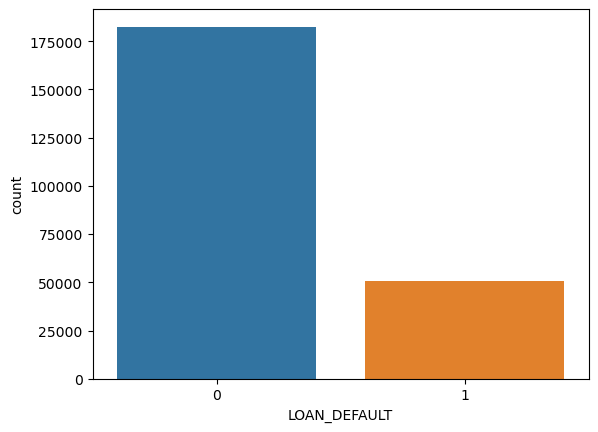

In [170]:
# plot loan default 
sns.countplot(x='LOAN_DEFAULT', data=loan_df)
plt.show()

## Missing Values

### Identifying Missing Data

In [171]:
loan_df.isnull().sum()

DISBURSED_AMOUNT                          0
ASSET_COST                                0
LTV                                       0
BRANCH_ID                                 0
SUPPLIER_ID                               0
MANUFACTURER_ID                           0
CURRENT_PINCODE_ID                        0
DATE_OF_BIRTH                             0
EMPLOYMENT_TYPE                        7661
DISBURSAL_DATE                            0
STATE_ID                                  0
EMPLOYEE_CODE_ID                          0
MOBILENO_AVL_FLAG                         0
AADHAR_FLAG                               0
PAN_FLAG                                  0
VOTERID_FLAG                              0
DRIVING_FLAG                              0
PASSPORT_FLAG                             0
PERFORM_CNS_SCORE                         0
PERFORM_CNS_SCORE_DESCRIPTION             0
PRI_NO_OF_ACCTS                           0
PRI_ACTIVE_ACCTS                          0
PRI_OVERDUE_ACCTS               

EMPLOYMENT_TYPE
Self employed    127635
Salaried          97858
Name: count, dtype: int64


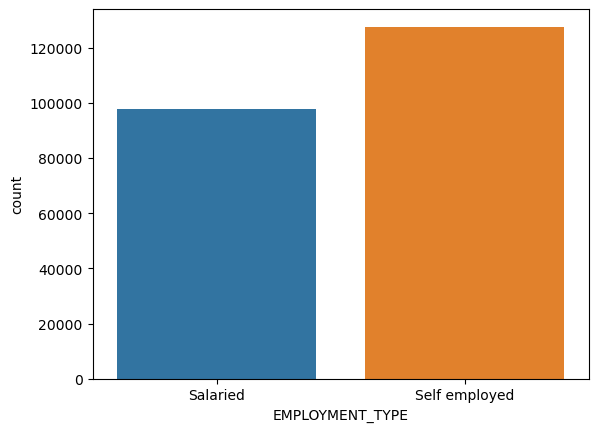

In [172]:
print(loan_df['EMPLOYMENT_TYPE'].value_counts())
sns.countplot(x="EMPLOYMENT_TYPE", data=loan_df)
plt.show()

In [173]:
loan_df = loan_df.fillna(value={'EMPLOYMENT_TYPE' : 'Missing'})

EMPLOYMENT_TYPE
Self employed    127635
Salaried          97858
Missing            7661
Name: count, dtype: int64


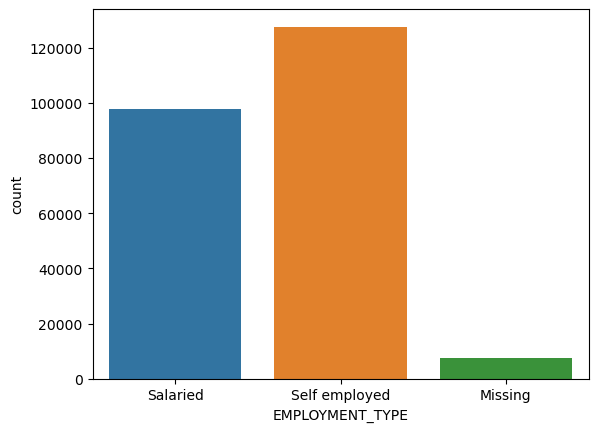

In [174]:
print(loan_df['EMPLOYMENT_TYPE'].value_counts())
sns.countplot(x="EMPLOYMENT_TYPE", data=loan_df)
plt.show()

## Dealing with Dates

- We have two date columns, DISBURSAL_DATE and DATE_OF_BIRTH
- These should be transformed into a more algorithm friendly format

In [175]:
# make sure thic colums are datetimes
loan_df['DATE_OF_BIRTH'] = pd.to_datetime(loan_df['DATE_OF_BIRTH'],format='mixed')
loan_df['DISBURSAL_DATE'] = pd.to_datetime(loan_df['DISBURSAL_DATE'],format='mixed')

print("DATE_OF_BIRTH variable type: ", loan_df['DATE_OF_BIRTH'].dtypes)
print("DISBURSAL_DATE variable type: ", loan_df['DISBURSAL_DATE'].dtypes)

DATE_OF_BIRTH variable type:  datetime64[ns]
DISBURSAL_DATE variable type:  datetime64[ns]


In [176]:
# calculate differences between them
loan_df['AGE'] = (loan_df['DISBURSAL_DATE'] - loan_df['DATE_OF_BIRTH']).dt.days // 365

#check result
print(loan_df[['DATE_OF_BIRTH', 'AGE', 'DISBURSAL_DATE']].sample(n=5))

         DATE_OF_BIRTH  AGE DISBURSAL_DATE
UNIQUEID                                  
435529      1993-08-09   25     2018-08-13
607556      1968-01-05   50     2018-10-23
428795      1982-05-01   36     2018-09-08
501470      1984-12-18   33     2018-12-09
571276      1964-12-09   54     2018-12-10


### Disbursal Month
### EXERCISE 
- Can you create a new column 'DISBURSAL_MONTH' to store the disbursal month as an integer

In [177]:
loan_df['DISBURSAL_MONTH'] = loan_df['DISBURSAL_DATE'].dt.month
loan_df['DISBURSAL_MONTH'].value_counts()

DISBURSAL_MONTH
10    84875
8     56975
9     54443
11     6709
6      5991
12     5613
3      5148
4      4627
7      4150
5      2890
1      1708
2        25
Name: count, dtype: int64

In [178]:
loan_df = loan_df.drop(['DISBURSAL_DATE', 'DATE_OF_BIRTH'], axis=1)

## Fix the Strings

- AVERAGE_ACCT_AGE and CREDIT_HISTORY_LENGTH were also strings 
- Column names suggest they should be numeric, let's take a look 

### String Fields

- Can select a subset of DataFrame columns by passing in a list of column names,  [indexing](https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html)
- [df.sample](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html) can be used to pull a random sample of n rows

In [179]:
loan_df[['CREDIT_HISTORY_LENGTH', 'AVERAGE_ACCT_AGE']].sample(n=10)

,CREDIT_HISTORY_LENGTH,AVERAGE_ACCT_AGE
UNIQUEID,,
652306,2yrs 6mon,1yrs 3mon
645882,3yrs 1mon,3yrs 1mon
578628,0yrs 0mon,0yrs 0mon
570006,0yrs 0mon,0yrs 0mon
483955,0yrs 0mon,0yrs 0mon
644863,0yrs 6mon,0yrs 6mon
432671,0yrs 0mon,0yrs 0mon
556877,8yrs 2mon,2yrs 1mon
539959,0yrs 0mon,0yrs 0mon


### String Manipulation

The current format of AVERAGE_ACCT_AGE and CREDIT_HISTORY_LENGTH is not useful

### EXERCISE

- Can you create a new column 'AVERAGE_ACCT_AGE_MONTHS' to store the average account age as an integer of months?

### Steps:
- Create a function which can calculate the total number of months based on a list of input strings
- Extract the relevant numbers from the original string data
- Use map to perform calc_months across all rows
- Check the results

In [180]:
#The calc_months function simply takes the list of two numbers stored in AVERAGE_ACCT_AGE_MONTHS
def calc_months(str_list):  
    years = int(str_list[0])
    months = int(str_list[1])

    num_months = (years * 12) + months
    return num_months

In [181]:
# str.findall can be used to find all instances of a string within a column
# the '\d+' is a regular expression which finds integers in a string

loan_df['AVERAGE_ACCT_AGE_MONTHS'] = loan_df['AVERAGE_ACCT_AGE'].str.findall('\d+')
print(loan_df['AVERAGE_ACCT_AGE_MONTHS'].sample(n=10))

UNIQUEID
545156     [0, 0]
518660    [0, 11]
453882     [4, 2]
500827    [0, 11]
641262     [0, 7]
575586     [0, 6]
603135     [0, 0]
556522     [0, 0]
476092     [0, 0]
489082     [0, 8]
Name: AVERAGE_ACCT_AGE_MONTHS, dtype: object


In [182]:
# Used map to apply a function which calculates the total number of months for each row in the dataframe
loan_df['AVERAGE_ACCT_AGE_MONTHS'] = loan_df['AVERAGE_ACCT_AGE_MONTHS'].map(calc_months)

### Step 4 - Inspect the results

In [183]:
# check results
print(loan_df[['AVERAGE_ACCT_AGE_MONTHS', 'AVERAGE_ACCT_AGE']].sample(n=10))

          AVERAGE_ACCT_AGE_MONTHS AVERAGE_ACCT_AGE
UNIQUEID                                          
498182                          2        0yrs 2mon
609250                          0        0yrs 0mon
481892                          0        0yrs 0mon
460539                         12        1yrs 0mon
611739                         19        1yrs 7mon
456573                         11       0yrs 11mon
642092                          0        0yrs 0mon
588546                         12        1yrs 0mon
552269                          9        0yrs 9mon
511781                         36        3yrs 0mon


### More String Manipulation

- Great, now we have fixed AVERAGE_ACCT_AGE how about CREDIT_HISTORY_LENGTH?
- We could simply copy and paste our solution from the previous exercise
- How about if we had 20 columns to fix instead of 2?

### EXERCISE

- Convert your solution to the previous exercise into a function and use it to fix CREDIT_HISTORY_LENGTH

In [184]:
def convert_str_to_months(col_name):
    new_col = col_name + '_MONTHS'
    loan_df[new_col] = loan_df[col_name].str.findall('\d+')
    loan_df[new_col] = loan_df[new_col].map(calc_months)

In [185]:
# check function
convert_str_to_months('CREDIT_HISTORY_LENGTH')
loan_df[['CREDIT_HISTORY_LENGTH_MONTHS', 'CREDIT_HISTORY_LENGTH']].sample(n=5)

,CREDIT_HISTORY_LENGTH_MONTHS,CREDIT_HISTORY_LENGTH
UNIQUEID,,
425739,0,0yrs 0mon
619508,0,0yrs 0mon
435079,11,0yrs 11mon
552416,0,0yrs 0mon
580686,46,3yrs 10mon


In [186]:
# drop the 'AVERAGE_ACCT_AGE', 'CREDIT_HISTORY_LENGTH' columns
loan_df = loan_df.drop(['AVERAGE_ACCT_AGE', 'CREDIT_HISTORY_LENGTH'], axis=1)

In [187]:
loan_df['PERFORM_CNS_SCORE_DESCRIPTION'].value_counts()

PERFORM_CNS_SCORE_DESCRIPTION
No Bureau History Available                                116950
C-Very Low Risk                                             16045
A-Very Low Risk                                             14124
D-Very Low Risk                                             11358
B-Very Low Risk                                              9201
M-Very High Risk                                             8776
F-Low Risk                                                   8485
K-High Risk                                                  8277
H-Medium Risk                                                6855
E-Low Risk                                                   5821
I-Medium Risk                                                5557
G-Low Risk                                                   3988
Not Scored: Sufficient History Not Available                 3765
J-High Risk                                                  3748
Not Scored: Not Enough Info available on the c

# Exploratory Data Analysis

In [188]:
# get info 
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 233154 entries, 420825 to 630213
Data columns (total 40 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   DISBURSED_AMOUNT                     233154 non-null  int64  
 1   ASSET_COST                           233154 non-null  int64  
 2   LTV                                  233154 non-null  float64
 3   BRANCH_ID                            233154 non-null  int64  
 4   SUPPLIER_ID                          233154 non-null  int64  
 5   MANUFACTURER_ID                      233154 non-null  int64  
 6   CURRENT_PINCODE_ID                   233154 non-null  int64  
 7   EMPLOYMENT_TYPE                      233154 non-null  object 
 8   STATE_ID                             233154 non-null  int64  
 9   EMPLOYEE_CODE_ID                     233154 non-null  int64  
 10  MOBILENO_AVL_FLAG                    233154 non-null  int64  
 11  AADHAR_FLAG  

### Unique Values 

In [189]:
loan_df.nunique()

DISBURSED_AMOUNT                       24565
ASSET_COST                             46252
LTV                                     6579
BRANCH_ID                                 82
SUPPLIER_ID                             2953
MANUFACTURER_ID                           11
CURRENT_PINCODE_ID                      6698
EMPLOYMENT_TYPE                            3
STATE_ID                                  22
EMPLOYEE_CODE_ID                        3270
MOBILENO_AVL_FLAG                          1
AADHAR_FLAG                                2
PAN_FLAG                                   2
VOTERID_FLAG                               2
DRIVING_FLAG                               2
PASSPORT_FLAG                              2
PERFORM_CNS_SCORE                        573
PERFORM_CNS_SCORE_DESCRIPTION             20
PRI_NO_OF_ACCTS                          108
PRI_ACTIVE_ACCTS                          40
PRI_OVERDUE_ACCTS                         22
PRI_CURRENT_BALANCE                    71341
PRI_SANCTI

In [190]:
#MOBILE_AVL_FLAG has only one unique value
loan_df['MOBILENO_AVL_FLAG'].value_counts()

MOBILENO_AVL_FLAG
1    233154
Name: count, dtype: int64

In [191]:
# MOBILENO_AVL_FLAG rows contains the value 1, drop it
loan_df = loan_df.drop(['MOBILENO_AVL_FLAG'], axis = 1)

In [192]:
# EDA for IDs column
loan_df[['SUPPLIER_ID', 'CURRENT_PINCODE_ID', 'EMPLOYEE_CODE_ID', 'BRANCH_ID', 'STATE_ID', 'MANUFACTURER_ID']].sample(6)

,SUPPLIER_ID,CURRENT_PINCODE_ID,EMPLOYEE_CODE_ID,BRANCH_ID,STATE_ID,MANUFACTURER_ID
UNIQUEID,,,,,,
501746,18655,3342,259,5,9,120
446676,14178,3379,678,5,9,86
425504,17285,2787,1636,147,2,86
552156,18732,6921,872,120,12,45
609848,18052,5312,1160,8,3,86
642000,16196,3461,1483,64,9,120


In [193]:
# Id fields with large numbers of unique values will introduce complexity into our predictive model. Drop them
loan_df = loan_df.drop(['SUPPLIER_ID', 'CURRENT_PINCODE_ID', 'EMPLOYEE_CODE_ID', 'BRANCH_ID'], axis=1)

### EXERCISE 

- Pick one of the two remaining Id columns and write some code to investigate its unique values


MANUFACTURER_ID
86     109534
45      56626
51      27204
48      16710
49      10220
120      9658
67       2405
145       778
153        12
152         6
156         1
Name: count, dtype: int64
MANUFACTURER_ID
86     0.469792
45     0.242870
51     0.116678
48     0.071669
49     0.043834
120    0.041423
67     0.010315
145    0.003337
153    0.000051
152    0.000026
156    0.000004
Name: proportion, dtype: float64


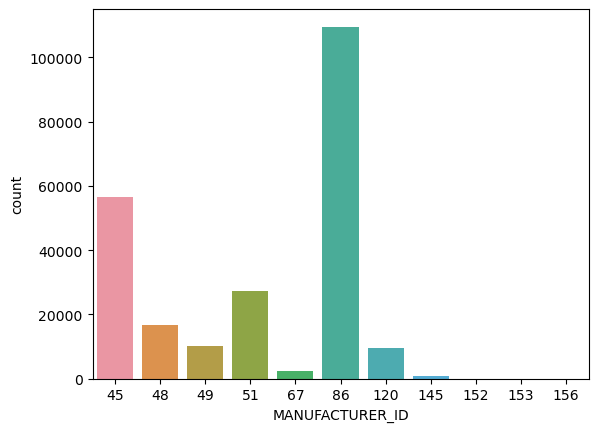

In [194]:
print(loan_df['MANUFACTURER_ID'].value_counts())
print(loan_df['MANUFACTURER_ID'].value_counts(normalize=True))
sns.countplot(x="MANUFACTURER_ID", data=loan_df)
plt.show()

In [195]:
# how loan defaults are distributed within manufacturer groups
loan_df.groupby('MANUFACTURER_ID')['LOAN_DEFAULT'].value_counts(normalize=True).unstack(level=-1)


LOAN_DEFAULT,0,1
MANUFACTURER_ID,,
45,0.771501,0.228499
48,0.727469,0.272531
49,0.781213,0.218787
51,0.792053,0.207947
67,0.782536,0.217464
86,0.795406,0.204594
120,0.779250,0.220750
145,0.799486,0.200514
152,1.000000,NaN


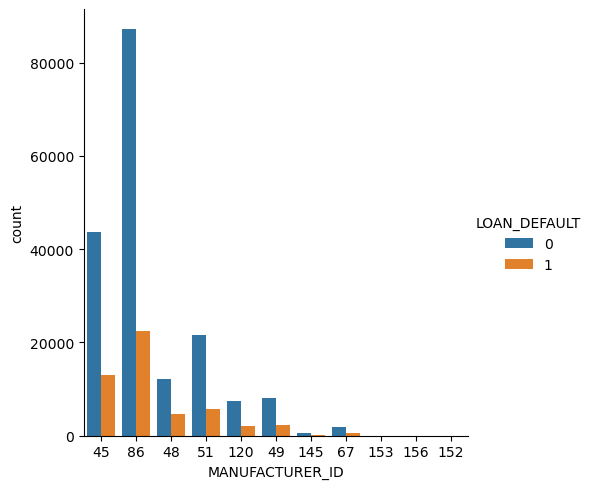

In [196]:
loan_df['MANUFACTURER_ID'] = loan_df['MANUFACTURER_ID'].astype(str)
loan_df['LOAN_DEFAULT'] = loan_df['LOAN_DEFAULT'].astype(str)

sns.catplot(data=loan_df,kind='count',x='MANUFACTURER_ID',hue='LOAN_DEFAULT')
plt.show()

## Reusable EDA

We still have 4 categorical variables to investigate!
- EMPLOYMENT_TYPE: Employment Type of the customer
- PERFORM_CNS_SCORE_DESCRIPTION: Bureau score description 
- STATE_ID: State of disbursement 
- DISBURSAL_MONTH: The month in which the loan was disbursed

In [197]:
# before i convert this columns (for test) astype(str) to avoid mistakes 'numpy.int64' object has no attribute 'startswith'
loan_df['EMPLOYMENT_TYPE'] = loan_df['EMPLOYMENT_TYPE'].astype(str)
loan_df['PERFORM_CNS_SCORE_DESCRIPTION'] = loan_df['PERFORM_CNS_SCORE_DESCRIPTION'].astype(str)
loan_df['STATE_ID'] = loan_df['STATE_ID'].astype(str)
loan_df['DISBURSAL_MONTH'] = loan_df['DISBURSAL_MONTH'].astype(str)


### EXERCISE 

- Write a function to perform the steps from lesson 2 for any column 
- Use this to explore the remaining categorical variables and think about their relationships with the target 

In [198]:
def explore_categorical(col_name):   
    print("{0} Summary".format(col_name))
    print("\n")

    print("{0} Counts".format(col_name))
    print(loan_df[col_name].value_counts())
    print("\n")

    print("{0} Ratio".format(col_name))
    print(loan_df[col_name].value_counts(normalize=True))
    print("\n")

    print("{0} Default Counts".format(col_name))
    print(loan_df.groupby(col_name)['LOAN_DEFAULT'].value_counts().unstack(level=-1))
    print("\n")

    print("{0} Default Ratio".format(col_name))
    print(loan_df.groupby(col_name)['LOAN_DEFAULT'].value_counts(normalize=True).unstack(level=-1))
    print("\n")

    sns.catplot(data=loan_df,kind='count',x=col_name,hue='LOAN_DEFAULT')
    plt.show()

DISBURSAL_MONTH Summary


DISBURSAL_MONTH Counts
DISBURSAL_MONTH
10    84875
8     56975
9     54443
11     6709
6      5991
12     5613
3      5148
4      4627
7      4150
5      2890
1      1708
2        25
Name: count, dtype: int64


DISBURSAL_MONTH Ratio
DISBURSAL_MONTH
10    0.364030
8     0.244366
9     0.233507
11    0.028775
6     0.025695
12    0.024074
3     0.022080
4     0.019845
7     0.017799
5     0.012395
1     0.007326
2     0.000107
Name: proportion, dtype: float64


DISBURSAL_MONTH Default Counts
LOAN_DEFAULT         0      1
DISBURSAL_MONTH              
1                 1316    392
10               64474  20401
11                5484   1225
12                4470   1143
2                   23      2
3                 4094   1054
4                 3636    991
5                 2279    611
6                 4697   1294
7                 3222    928
8                44938  12037
9                43910  10533


DISBURSAL_MONTH Default Ratio
LOAN_DEFAULT            0  

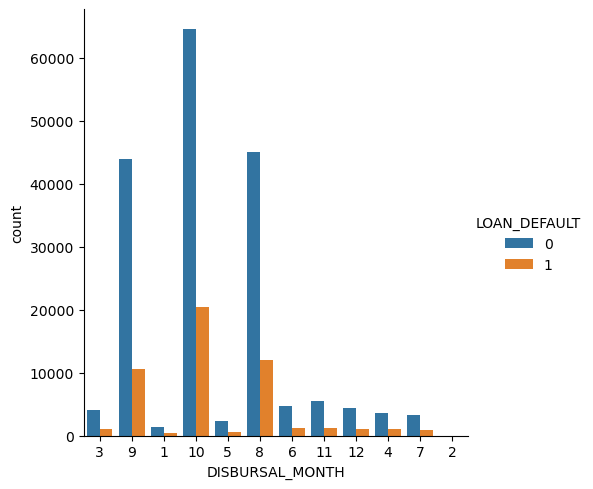

In [199]:
# test the explore_categorical function

explore_categorical("DISBURSAL_MONTH")

## Continuous Variables 

### Summary Statistics

In [200]:
loan_df["AGE"].describe()

count    233154.000000
mean         33.918037
std           9.831623
min          17.000000
25%          26.000000
50%          32.000000
75%          41.000000
max          69.000000
Name: AGE, dtype: float64

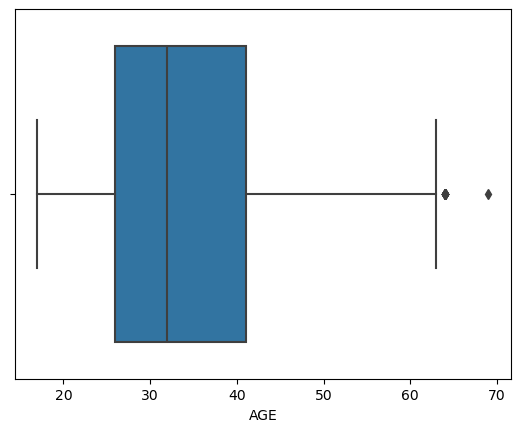

In [201]:
sns.boxplot(x="AGE", data=loan_df)
plt.show()

In [202]:
loan_df.groupby('LOAN_DEFAULT')['AGE'].describe()

,count,mean,std,min,25%,50%,75%,max
LOAN_DEFAULT,,,,,,,,
0,182543.0,34.106391,9.863022,17.0,26.0,32.0,41.0,69.0
1,50611.0,33.238683,9.687248,17.0,25.0,31.0,40.0,64.0


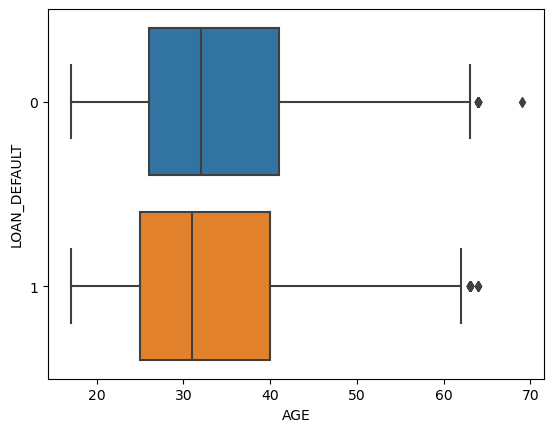

In [203]:
sns.boxplot(x='AGE', y='LOAN_DEFAULT', data=loan_df, orient="h")
plt.show()

### EXERCISE 

- Using the steps we have performed to explore ‘AGE’, write a function that can be used to explore other continuous variables
- Pick a few more continuous variables to explore and use your function to investigate them!
- Keep a note of your findings

In [204]:
def explore_continuous(col_name):
    #print statistical summary
    print("{0} Summary".format(col_name))
    print("\n")
    print(loan_df[col_name].describe())
    print("\n")

    #Look at boxplot
    sns.boxplot(x=col_name, data=loan_df)
    plt.show()

    #Now lets look deeper by grouping with the target variable 
    print("{0} Grouped Summary".format(col_name))
    print("\n")
    print(loan_df.groupby('LOAN_DEFAULT')[col_name].describe())

    #look at grouped boxplot 
    sns.boxplot(x=col_name, y='LOAN_DEFAULT', data=loan_df, orient="h")
    plt.show()

DISBURSED_AMOUNT Summary


count    233154.000000
mean      54356.993528
std       12971.314171
min       13320.000000
25%       47145.000000
50%       53803.000000
75%       60413.000000
max      990572.000000
Name: DISBURSED_AMOUNT, dtype: float64




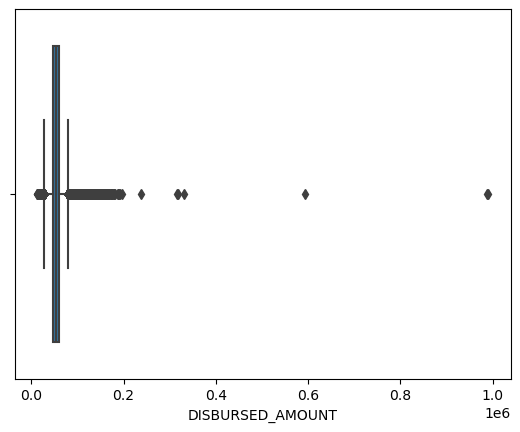

DISBURSED_AMOUNT Grouped Summary


                 count          mean           std      min      25%      50%  \
LOAN_DEFAULT                                                                    
0             182543.0  53826.471111  13140.699007  13320.0  46369.0  53303.0   
1              50611.0  56270.473869  12150.255527  13369.0  49303.0  55459.0   

                  75%       max  
LOAN_DEFAULT                     
0             59947.0  990572.0  
1             61947.0  191392.0  


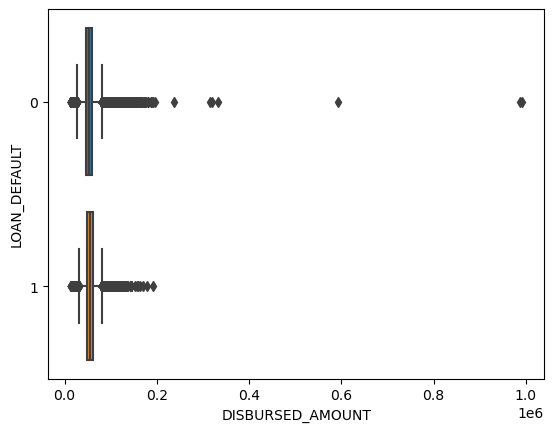

In [205]:
explore_continuous('DISBURSED_AMOUNT')

# Feature Engineering

## Binning

In [206]:
# get row index of max disb. amount
loan_df['DISBURSED_AMOUNT'].idxmax()

440173

In [207]:
#idmax to get row

loan_df.loc[loan_df['DISBURSED_AMOUNT'].idxmax()]

DISBURSED_AMOUNT                                                                  990572
ASSET_COST                                                                       1628992
LTV                                                                                61.39
MANUFACTURER_ID                                                                      152
EMPLOYMENT_TYPE                                                                  Missing
STATE_ID                                                                               9
AADHAR_FLAG                                                                            1
PAN_FLAG                                                                               1
VOTERID_FLAG                                                                           0
DRIVING_FLAG                                                                           0
PASSPORT_FLAG                                                                          0
PERFORM_CNS_SCORE    

In [208]:
# create some bins based on the disbursed amount
disbursed_buckets = [13000, 30000, 45000, 60000, 75000, 150000, 1000000]
disbursed_labels = ['13k - 30k', '30k - 45k', '45k - 60k', '60k - 75k', '75k - 150k', '150k - 1m']

In [209]:
# use these bins to categorize  rows based on their disbursed amounts with cut to assighn to new buckets
loan_df['DISBURSED_CAT'] = pd.cut(loan_df['DISBURSED_AMOUNT'], disbursed_buckets, labels=disbursed_labels)

DISBURSED_CAT Summary


DISBURSED_CAT Counts
DISBURSED_CAT
45k - 60k     126904
60k - 75k      49824
30k - 45k      40626
75k - 150k     10871
13k - 30k       4865
150k - 1m         64
Name: count, dtype: int64


DISBURSED_CAT Ratio
DISBURSED_CAT
45k - 60k     0.544293
60k - 75k     0.213696
30k - 45k     0.174245
75k - 150k    0.046626
13k - 30k     0.020866
150k - 1m     0.000274
Name: proportion, dtype: float64


DISBURSED_CAT Default Counts
LOAN_DEFAULT       0      1
DISBURSED_CAT              
13k - 30k       4207    658
30k - 45k      34323   6303
45k - 60k      98830  28074
60k - 75k      37056  12768
75k - 150k      8070   2801
150k - 1m         57      7


DISBURSED_CAT Default Ratio
LOAN_DEFAULT          0         1
DISBURSED_CAT                    
13k - 30k      0.864748  0.135252
30k - 45k      0.844853  0.155147
45k - 60k      0.778778  0.221222
60k - 75k      0.743738  0.256262
75k - 150k     0.742342  0.257658
150k - 1m      0.890625  0.109375




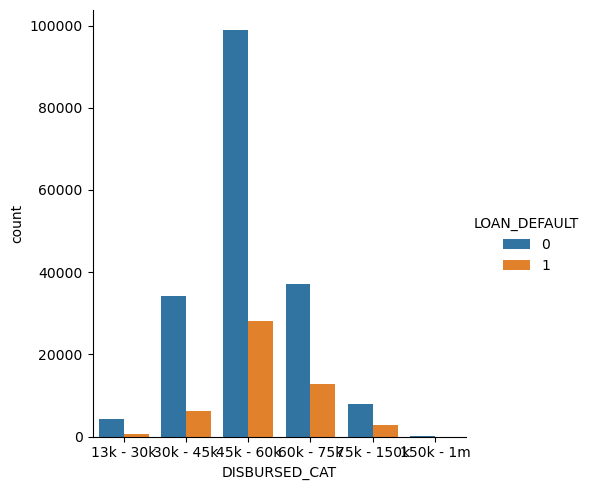

In [210]:
# check results

explore_categorical('DISBURSED_CAT')

## Combine Features

In [211]:
# disb. difference
loan_df['DISBURSAL_DIFFERENCE'] = loan_df['ASSET_COST'] - loan_df['DISBURSED_AMOUNT']

In [212]:
# check results
loan_df[['DISBURSAL_DIFFERENCE', 'ASSET_COST', 'DISBURSED_AMOUNT']].sample(10)

,DISBURSAL_DIFFERENCE,ASSET_COST,DISBURSED_AMOUNT
UNIQUEID,,,
587559,25560,98683,73123
529662,12713,73926,61213
437488,20779,67128,46349
565915,16447,72810,56363
565043,15493,70006,54513
449546,26515,77818,51303
568312,35473,107550,72077
561221,20281,89150,68869
565079,21751,74529,52778


In [213]:
# new total acc
loan_df['TOTAL_ACCTS'] = loan_df['PRI_NO_OF_ACCTS'] + loan_df['SEC_NO_OF_ACCTS']

In [214]:
# check total_acc
loan_df[['TOTAL_ACCTS', 'PRI_NO_OF_ACCTS', 'SEC_NO_OF_ACCTS']].sample(10)

,TOTAL_ACCTS,PRI_NO_OF_ACCTS,SEC_NO_OF_ACCTS
UNIQUEID,,,
453169,0,0,0
528972,0,0,0
422765,0,0,0
501621,0,0,0
562797,1,1,0
417644,0,0,0
421888,1,1,0
418217,2,2,0
524686,0,0,0


### EXERCISE

- Create TOTAL_ columns from the remaining primary/secondary variables

In [215]:
loan_df['TOTAL_ACTIVE_ACCTS'] = loan_df['PRI_ACTIVE_ACCTS'] + loan_df['SEC_ACTIVE_ACCTS']
loan_df['TOTAL_OVERDUE_ACCTS'] = loan_df['PRI_OVERDUE_ACCTS'] + loan_df['SEC_OVERDUE_ACCTS']
loan_df['TOTAL_CURRENT_BALANCE'] = loan_df['PRI_CURRENT_BALANCE'] + loan_df['SEC_CURRENT_BALANCE']
loan_df['TOTAL_SANCTIONED_AMOUNT'] = loan_df['PRI_SANCTIONED_AMOUNT'] + loan_df['SEC_SANCTIONED_AMOUNT'] 
loan_df['TOTAL_DISBURSED_AMOUNT'] = loan_df['PRI_DISBURSED_AMOUNT'] + loan_df['SEC_DISBURSED_AMOUNT']
loan_df['TOTAL_INSTAL_AMT'] = loan_df['PRIMARY_INSTAL_AMT'] + loan_df['SEC_INSTAL_AMT']

In [216]:
# have to drop the columns to avoid duplication
drop_cols = ['PRI_NO_OF_ACCTS', 
             'PRI_ACTIVE_ACCTS', 
             'PRI_OVERDUE_ACCTS', 
             'PRI_CURRENT_BALANCE', 
             'PRI_SANCTIONED_AMOUNT', 
             'PRI_DISBURSED_AMOUNT', 
             'PRIMARY_INSTAL_AMT', 
             'SEC_NO_OF_ACCTS', 
             'SEC_ACTIVE_ACCTS', 
             'SEC_OVERDUE_ACCTS', 
             'SEC_CURRENT_BALANCE', 
             'SEC_SANCTIONED_AMOUNT', 
             'SEC_DISBURSED_AMOUNT', 
             'SEC_INSTAL_AMT']

loan_df = loan_df.drop(drop_cols, axis=1)


### EXERCISE

- Create a column 'OVERDUE_PCT' that stores the percentage of overdue accounts

In [217]:
loan_df['OVERDUE_PCT'] = loan_df['TOTAL_OVERDUE_ACCTS'] / loan_df['TOTAL_ACCTS']

In [218]:
# check null
loan_df['OVERDUE_PCT'].isnull().sum()

115792

In [219]:
# have to fill missing value
loan_df['OVERDUE_PCT'] = loan_df['OVERDUE_PCT'].fillna(0)

In [220]:
loan_df['OVERDUE_PCT'].isnull().sum()

0

In [221]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 233154 entries, 420825 to 630213
Data columns (total 31 columns):
 #   Column                               Non-Null Count   Dtype   
---  ------                               --------------   -----   
 0   DISBURSED_AMOUNT                     233154 non-null  int64   
 1   ASSET_COST                           233154 non-null  int64   
 2   LTV                                  233154 non-null  float64 
 3   MANUFACTURER_ID                      233154 non-null  object  
 4   EMPLOYMENT_TYPE                      233154 non-null  object  
 5   STATE_ID                             233154 non-null  object  
 6   AADHAR_FLAG                          233154 non-null  int64   
 7   PAN_FLAG                             233154 non-null  int64   
 8   VOTERID_FLAG                         233154 non-null  int64   
 9   DRIVING_FLAG                         233154 non-null  int64   
 10  PASSPORT_FLAG                        233154 non-null  int64   
 11  

## Scaling 

In [222]:
# list of numeric columns

numeric_cols = ['DISBURSED_AMOUNT', 
                'ASSET_COST', 
                'LTV', 
                'NEW_ACCTS_IN_LAST_SIX_MONTHS', 
                'DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS', 
                'NO_OF_INQUIRIES', 
                'AGE', 
                'AVERAGE_ACCT_AGE_MONTHS', 
                'CREDIT_HISTORY_LENGTH_MONTHS',
                'PERFORM_CNS_SCORE',
                'TOTAL_ACCTS',
                'TOTAL_ACTIVE_ACCTS',
                'TOTAL_OVERDUE_ACCTS',
                'TOTAL_CURRENT_BALANCE', 
                'TOTAL_SANCTIONED_AMOUNT', 
                'TOTAL_DISBURSED_AMOUNT', 
                'TOTAL_INSTAL_AMT', 
                'OVERDUE_PCT', 
                'DISBURSAL_DIFFERENCE']

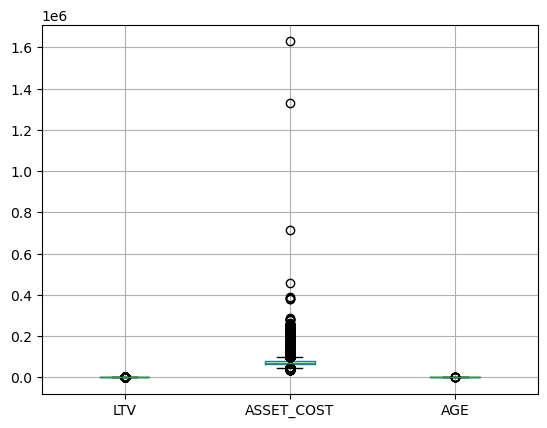

In [223]:
# check the problem with columns

loan_df[['LTV', 'ASSET_COST', 'AGE']].boxplot()
plt.show()

In [224]:
# use min max scaler
mm_scaler = MinMaxScaler()

In [225]:
# fit the scaler to our data and perform the scaling
loan_df[numeric_cols] = mm_scaler.fit_transform(loan_df[numeric_cols])

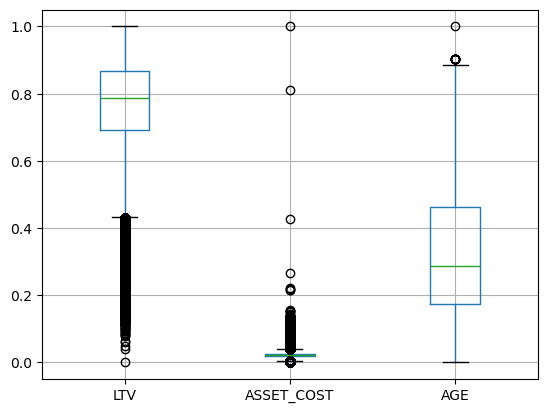

In [226]:
# check results
loan_df[['LTV', 'ASSET_COST', 'AGE']].boxplot()
plt.show()

# Linear Classifiers

## Train/Test Split

In [227]:
# review data 
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 233154 entries, 420825 to 630213
Data columns (total 31 columns):
 #   Column                               Non-Null Count   Dtype   
---  ------                               --------------   -----   
 0   DISBURSED_AMOUNT                     233154 non-null  float64 
 1   ASSET_COST                           233154 non-null  float64 
 2   LTV                                  233154 non-null  float64 
 3   MANUFACTURER_ID                      233154 non-null  object  
 4   EMPLOYMENT_TYPE                      233154 non-null  object  
 5   STATE_ID                             233154 non-null  object  
 6   AADHAR_FLAG                          233154 non-null  int64   
 7   PAN_FLAG                             233154 non-null  int64   
 8   VOTERID_FLAG                         233154 non-null  int64   
 9   DRIVING_FLAG                         233154 non-null  int64   
 10  PASSPORT_FLAG                        233154 non-null  int64   
 11  

In [228]:
# check categorical feilds
category_cols = ['MANUFACTURER_ID', 'STATE_ID', 'DISBURSAL_MONTH', 'DISBURSED_CAT', 'PERFORM_CNS_SCORE_DESCRIPTION', 'EMPLOYMENT_TYPE']
loan_df[category_cols].dtypes

MANUFACTURER_ID                    object
STATE_ID                           object
DISBURSAL_MONTH                    object
DISBURSED_CAT                    category
PERFORM_CNS_SCORE_DESCRIPTION      object
EMPLOYMENT_TYPE                    object
dtype: object

In [229]:
# encode categorical columns  as category astype
loan_df[category_cols] = loan_df[category_cols].astype('category')
loan_df[category_cols].dtypes

MANUFACTURER_ID                  category
STATE_ID                         category
DISBURSAL_MONTH                  category
DISBURSED_CAT                    category
PERFORM_CNS_SCORE_DESCRIPTION    category
EMPLOYMENT_TYPE                  category
dtype: object

### EXERCISE 

- To keep our first model simple, select 6 variables including 'LOAN_DEFAULT' and 'DISBURSED_CAT'
- Using these variables create a subset of loan_df and store it as a separate DataFrame loan_df_sml

In [237]:
loan_df['LOAN_DEFAULT'] = loan_df['LOAN_DEFAULT'].astype('int64')

In [238]:
small_cols = ['STATE_ID', 'LTV', 'DISBURSED_CAT', 'PERFORM_CNS_SCORE', 'DISBURSAL_MONTH', 'LOAN_DEFAULT']

loan_df_sml = loan_df[small_cols]

In [239]:
# check the results loan_df_sml
print(f"shape:{loan_df_sml.shape}")
print(f"-------------------------")
loan_df_sml.info()


shape:(233154, 6)
-------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 233154 entries, 420825 to 630213
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   STATE_ID           233154 non-null  category
 1   LTV                233154 non-null  float64 
 2   DISBURSED_CAT      233154 non-null  category
 3   PERFORM_CNS_SCORE  233154 non-null  float64 
 4   DISBURSAL_MONTH    233154 non-null  category
 5   LOAN_DEFAULT       233154 non-null  int64   
dtypes: category(3), float64(2), int64(1)
memory usage: 15.8 MB


### Training/Test Split

### EXERCISE

- Create two variables x and y to match the required parameters for train_test_split

In [240]:
x = loan_df_sml.drop(['LOAN_DEFAULT'], axis=1)
y = loan_df_sml['LOAN_DEFAULT']

In [241]:
# check result
print("x has {0} rows and {1} columns".format(x.shape[0], x.shape[1]))
print("y has {0} rows".format(y.count()))

x has 233154 rows and 5 columns
y has 233154 rows


In [242]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 233154 entries, 420825 to 630213
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   STATE_ID           233154 non-null  category
 1   LTV                233154 non-null  float64 
 2   DISBURSED_CAT      233154 non-null  category
 3   PERFORM_CNS_SCORE  233154 non-null  float64 
 4   DISBURSAL_MONTH    233154 non-null  category
dtypes: category(3), float64(2)
memory usage: 14.1 MB


In [243]:
y.dtype

dtype('int64')

In [245]:
# train test split
# - x_train: the training rows without the target variable 
# - x_test: the test rows without the target variable 
# - y_train: the training rows, target variable only 
# - y_test: the test rows, target variable only 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [246]:
# check results 
print("x_train has {0} rows and {1} columns".format(x_train.shape[0], x_train.shape[1]))
print("x_test has {0} rows and {1} columns".format(x_test.shape[0], x_test.shape[1]))
print("y_train has {0} rows".format(y_train.count()))
print("y_test has {0} rows".format(y_test.count()))

x_train has 186523 rows and 5 columns
x_test has 46631 rows and 5 columns
y_train has 186523 rows
y_test has 46631 rows


In [247]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186523 entries, 633275 to 501520
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   STATE_ID           186523 non-null  category
 1   LTV                186523 non-null  float64 
 2   DISBURSED_CAT      186523 non-null  category
 3   PERFORM_CNS_SCORE  186523 non-null  float64 
 4   DISBURSAL_MONTH    186523 non-null  category
dtypes: category(3), float64(2)
memory usage: 4.8 MB


In [248]:
y_train.head()

UNIQUEID
633275    1
646002    0
591252    0
475736    0
639478    0
Name: LOAN_DEFAULT, dtype: int64

In [249]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46631 entries, 617183 to 626383
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   STATE_ID           46631 non-null  category
 1   LTV                46631 non-null  float64 
 2   DISBURSED_CAT      46631 non-null  category
 3   PERFORM_CNS_SCORE  46631 non-null  float64 
 4   DISBURSAL_MONTH    46631 non-null  category
dtypes: category(3), float64(2)
memory usage: 1.2 MB


In [250]:
y_test.head()

UNIQUEID
617183    1
515702    0
466872    0
632384    0
461426    0
Name: LOAN_DEFAULT, dtype: int64

In [251]:
# training target 
y_train.value_counts(normalize=True)

LOAN_DEFAULT
0    0.783099
1    0.216901
Name: proportion, dtype: float64

In [252]:
y_test.value_counts(normalize=True)

LOAN_DEFAULT
0    0.782248
1    0.217752
Name: proportion, dtype: float64

## Variable Encoding

In [253]:
# initialize the model 
logistic_model = LogisticRegression()

### One Hot Encoding 

In [255]:
#  One Hot Encoding 
loan_data_dumm = pd.get_dummies(loan_df_sml, prefix_sep='_', drop_first=True)

In [256]:
# check results
loan_data_dumm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 233154 entries, 420825 to 630213
Data columns (total 40 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   LTV                       233154 non-null  float64
 1   PERFORM_CNS_SCORE         233154 non-null  float64
 2   LOAN_DEFAULT              233154 non-null  int64  
 3   STATE_ID_10               233154 non-null  bool   
 4   STATE_ID_11               233154 non-null  bool   
 5   STATE_ID_12               233154 non-null  bool   
 6   STATE_ID_13               233154 non-null  bool   
 7   STATE_ID_14               233154 non-null  bool   
 8   STATE_ID_15               233154 non-null  bool   
 9   STATE_ID_16               233154 non-null  bool   
 10  STATE_ID_17               233154 non-null  bool   
 11  STATE_ID_18               233154 non-null  bool   
 12  STATE_ID_19               233154 non-null  bool   
 13  STATE_ID_2                233154 non-null  b

### EXERCISE 

- Take time to investigate the contents these new columns 
- Make sure you understand how pd.get_dummies

In [257]:
print(loan_data_dumm['STATE_ID_13'].value_counts())
print(loan_data_dumm['STATE_ID_13'].value_counts(normalize=True))

print(loan_data_dumm['DISBURSAL_MONTH_10'].value_counts())
print(loan_data_dumm['DISBURSAL_MONTH_10'].value_counts(normalize=True))

STATE_ID_13
False    215270
True      17884
Name: count, dtype: int64
STATE_ID_13
False    0.923295
True     0.076705
Name: proportion, dtype: float64
DISBURSAL_MONTH_10
False    148279
True      84875
Name: count, dtype: int64
DISBURSAL_MONTH_10
False    0.63597
True     0.36403
Name: proportion, dtype: float64


## Train and Validate

### EXERCISE 

- Recreate our training and test set using loan_data_dumm
- Make sure the class distributions are correct

In [258]:
x = loan_data_dumm.drop(['LOAN_DEFAULT'], axis=1)
y = loan_data_dumm['LOAN_DEFAULT']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

LOAN_DEFAULT
0    0.782975
1    0.217025
Name: proportion, dtype: float64
LOAN_DEFAULT
0    0.782821
1    0.217179
Name: proportion, dtype: float64


In [259]:
# fit model
logistic_model = LogisticRegression(max_iter=200)
logistic_model.fit(x_train, y_train)

LogisticRegression(max_iter=200)

In [260]:
# generate predictions
preds = logistic_model.predict(x_test)
preds

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [261]:
# accuracy
logistic_model.score(x_test, y_test)

0.7828212789683617

# Model Evaluation

## Introduction

In [262]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, recall_score, roc_curve, auc, precision_score, ConfusionMatrixDisplay

### EXERCISE

- Can you build the same simple logistic regression model we created in the previous chapter
- If you find it easier you can add additional code cells to breakdown the exercise into smaller chunks

In [263]:
category_cols = ['MANUFACTURER_ID', 'STATE_ID', 'DISBURSAL_MONTH', 'DISBURSED_CAT', 'PERFORM_CNS_SCORE_DESCRIPTION', 'EMPLOYMENT_TYPE']
loan_df[category_cols] = loan_df[category_cols].astype('category')

In [264]:
small_cols = ['STATE_ID', 'LTV', 'DISBURSED_CAT', 'PERFORM_CNS_SCORE', 'DISBURSAL_MONTH', 'LOAN_DEFAULT']
loan_df_sml = loan_df[small_cols]

loan_data_dumm = pd.get_dummies(loan_df_sml, prefix_sep='_', drop_first=True)

x = loan_data_dumm.drop(['LOAN_DEFAULT'], axis=1)
y = loan_data_dumm['LOAN_DEFAULT']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

logistic_model = LogisticRegression(max_iter=200)
logistic_model.fit(x_train, y_train)

LogisticRegression(max_iter=200)

In [265]:
# get accuracy
logistic_model.score(x_test, y_test)

0.7822907507881023

## Evaluation Metrics

### Confusion Matrix

In [266]:
# get model predictions
preds = logistic_model.predict(x_test)
preds

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [267]:
# confusion matrix
conf_mat = confusion_matrix(y_test, preds)
conf_mat

array([[36476,     1],
       [10151,     3]], dtype=int64)

In [272]:
# extract values
tn = conf_mat[0][0]
fp = conf_mat[0][1]
fn = conf_mat[1][0]
tp = conf_mat[1][1]

print("True Negatives (Correct Non-Defaults): ", tn)
print("False Positives (Incorrect Defaults): ", fp)
print("False Negatives (Incorrect Non-Defaults): ", fn)
print("True Positives (Correct Defaults)", tp)


True Negatives (Correct Non-Defaults):  36476
False Positives (Incorrect Defaults):  1
False Negatives (Incorrect Non-Defaults):  10151
True Positives (Correct Defaults) 3



### Precision  = TP/TP + FP

In [273]:
# Precision
precision = precision_score(y_test, preds)
precision

0.75

### Recall = TP/TP + FN

In [274]:
# recall
recall = recall_score(y_test, preds)
recall

0.00029545006893834944

### F1 Score = 2((precision * recall)/(precision + recall))

In [276]:
# f1 score
f1 = f1_score(y_test, preds)
f1

0.0005906674542232723

## Roc Curve

In [277]:
# get predicted probabilities
probs = logistic_model.predict_proba(x_test)
probs

array([[0.71532202, 0.28467798],
       [0.82073092, 0.17926908],
       [0.79459003, 0.20540997],
       ...,
       [0.77468572, 0.22531428],
       [0.90237294, 0.09762706],
       [0.7421985 , 0.2578015 ]])

In [278]:
probs.shape

(46631, 2)

In [279]:
print(probs[:, 0])
print(probs[:, 1])

[0.71532202 0.82073092 0.79459003 ... 0.77468572 0.90237294 0.7421985 ]
[0.28467798 0.17926908 0.20540997 ... 0.22531428 0.09762706 0.2578015 ]


In [280]:
# create dataframe 
probs_df = pd.DataFrame()
probs_df['prob_0'] = probs[:, 0]
probs_df['prob_1'] = probs[:, 1]

probs_df.describe()

,prob_0,prob_1
count,46631.000000,46631.000000
mean,0.783698,0.216302
std,0.067745,0.067745
min,0.480090,0.035108
25%,0.740020,0.169161
50%,0.787240,0.212760
75%,0.830839,0.259980
max,0.964892,0.519910


### Plotting the ROC Curve

In [281]:
#roc
fpr, tpr, threshold = roc_curve(y_test, probs[:,1], pos_label=1)

In [282]:
# roc results
print("FPR: ", fpr)
print("TPR: ", tpr)
print("Threshold: ", threshold)

FPR:  [0.00000000e+00 2.74145352e-05 2.74145352e-05 ... 9.99725855e-01
 9.99725855e-01 1.00000000e+00]
TPR:  [0.00000000e+00 9.84833563e-05 2.95450069e-04 ... 9.99901517e-01
 1.00000000e+00 1.00000000e+00]
Threshold:  [1.51990995 0.51990995 0.50723294 ... 0.04978434 0.04969146 0.03510823]


In [283]:
# roc dataframe
roc_df = pd.DataFrame()
roc_df['fpr'] = fpr
roc_df['tpr'] = tpr
roc_df['threshold'] = threshold

roc_df.describe()

,fpr,tpr,threshold
count,16466.000000,16466.000000,16466.000000
mean,0.412983,0.524305,0.230985
std,0.274849,0.286942,0.067133
min,0.000000,0.000000,0.035108
25%,0.176234,0.277034,0.185712
50%,0.381144,0.535405,0.227611
75%,0.629136,0.774842,0.271540
max,1.000000,1.000000,1.519910


In [284]:
# auc
roc_auc = auc(fpr, tpr)
print("AUC: ", roc_auc)

AUC:  0.6095898905950535


In [285]:
# plot function
def plot_roc_curve(fpr, tpr, roc_auc):
    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

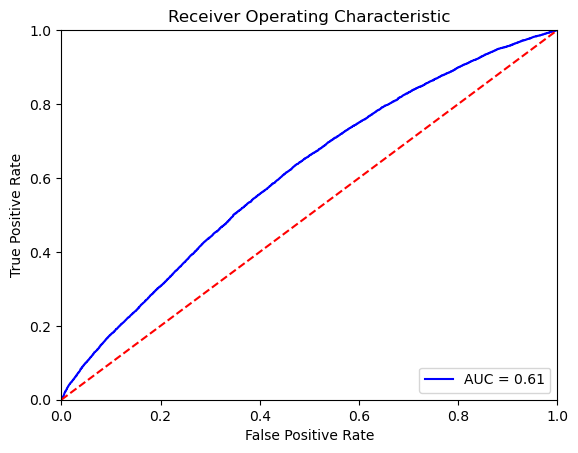

In [286]:
# create plot
plot_roc_curve(fpr, tpr, roc_auc)

## Advanced Evaluation

In [287]:
# results dataframe
results_df = pd.DataFrame()
results_df['true_class'] = y_test
results_df['predicted_class'] = list(preds)
results_df['default_prob'] = probs[:, 1]

### EXERCISE

- Using df.groupby can you print the above-mentioned metrics
- Feel free to look back at examples of groupby and value_counts from earlier in the course

In [288]:
results_df.groupby('true_class')['predicted_class'].value_counts(normalize=True)

true_class  predicted_class
0           0                  0.999973
            1                  0.000027
1           0                  0.999705
            1                  0.000295
Name: proportion, dtype: float64

### Class Probability Distributions

In [289]:
default_probs_f = results_df[results_df['true_class'] == 0]['default_prob']

### EXERCISE

- Use pandas filtering to create a variable default_probs_t which contains the predicted default probability for all true defaulted loans

In [290]:
default_probs_t = results_df[results_df['true_class'] == 1]['default_prob']

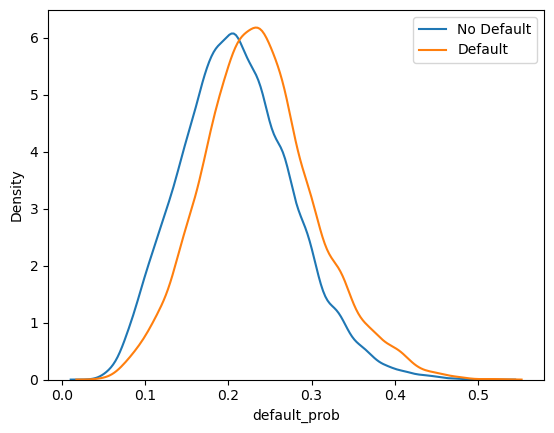

In [292]:
# plot distributions
sns.kdeplot(default_probs_f, label="No Default", fill=False)
sns.kdeplot(default_probs_t, label="Default", fill=False)
plt.legend(loc = 'best')
plt.show()

### EXERCISE

We have discussed some fundamental techniques for evaluating your model, as with everything, in the real world building predictive models requires several iterations
therefore it is a good idea to wrap up your evaluation code into a reusable function.

Based on what we have discussed please fill in the function declaration below to create a reusable evaluation function

In [295]:
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
def eval_model(model, x_test, y_test):
    
    preds = model.predict(x_test)
    probs = model.predict_proba(x_test)

   
    accuracy = accuracy_score(y_test, preds)
    recall = recall_score(y_test, preds)
    precision = precision_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    
    print("\n")
    print("Accuracy: ", accuracy)
    print("Precision: ", precision)
    print("Recall: ", recall)
    print("F1: ", f1)

    
    cm = confusion_matrix(y_test, preds)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    cm_display.plot(cmap='Blues')
    plt.show()

    
    fpr, tpr, threshold = roc_curve(y_test, probs[:,1], pos_label=1)
    roc_auc = auc(fpr, tpr)
    print("AUC: ", roc_auc)

    
    plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='best')
    plt.show()

   
    results_df = pd.DataFrame()
    results_df['true_class'] = y_test
    results_df['predicted_class'] = list(preds)
    results_df['default_prob'] = probs[:, 1]

  
    sns.kdeplot(results_df[results_df['true_class'] == 0]['default_prob'], label="No Default", fill=False)
    sns.kdeplot(results_df[results_df['true_class'] == 1]['default_prob'], label="Default", fill=False)
    plt.show()

    
    print(results_df.groupby('true_class')['predicted_class'].value_counts(normalize=True))



Accuracy:  0.7822907507881023
Precision:  0.75
Recall:  0.00029545006893834944
F1:  0.0005906674542232723


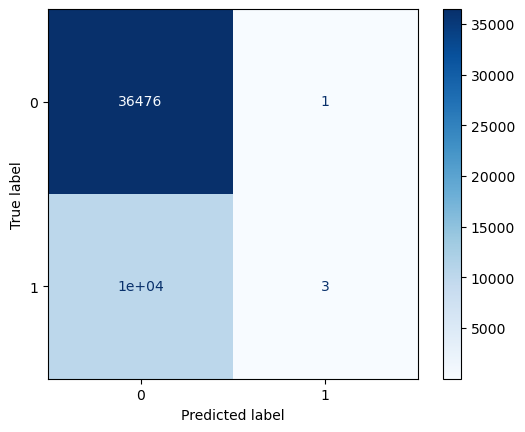

AUC:  0.6095898905950535


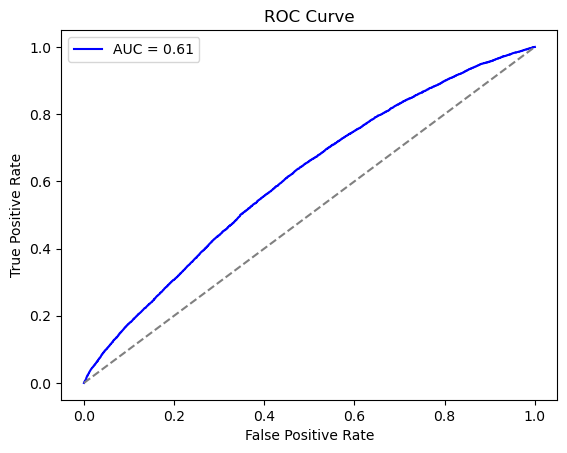

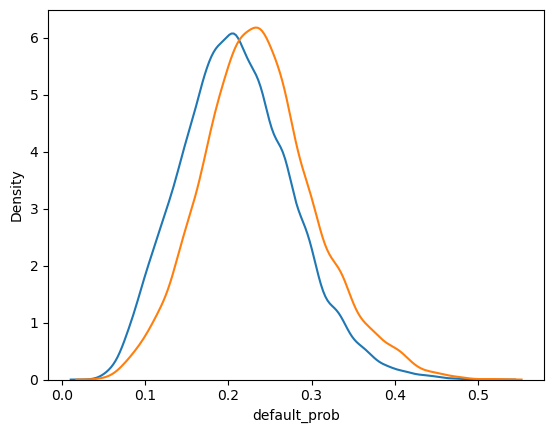

true_class  predicted_class
0           0                  0.999973
            1                  0.000027
1           0                  0.999705
            1                  0.000295
Name: proportion, dtype: float64


In [301]:
eval_model(logistic_model, x_test, y_test)

# Random Forest

### Recap and Load

In [302]:
from sklearn.ensemble import RandomForestClassifier

## Building The Forest

### EXERCISE 

- We seem to be duplicating the code for creating training/test sets and dummy variables 
- Fill in the function definition below to take in a data frame, create dummy variables and split the data into train/test sets 
- The return statement has been filled out for you

In [304]:
def encode_and_split(loan_df):
    loan_data_dumm = pd.get_dummies(loan_df, prefix_sep='_', drop_first=True)

    x = loan_data_dumm.drop(['LOAN_DEFAULT'], axis=1)
    y = loan_data_dumm['LOAN_DEFAULT']

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    return x_train, x_test, y_train, y_test

In [305]:
# encode_and_split
x_train, x_test, y_train, y_test = encode_and_split(loan_df)

In [309]:
print("Training Features Shape", x_train.shape)
print("Training Label Rows", y_train.count())
print("------------------------------------")
print("Testing Features Shape", x_test.shape)
print("Testing Label Rows", y_test.count())
print("------------------------------------")
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Training Features Shape (186523, 92)
Training Label Rows 186523
------------------------------------
Testing Features Shape (46631, 92)
Testing Label Rows 46631
------------------------------------
LOAN_DEFAULT
0    0.783099
1    0.216901
Name: proportion, dtype: float64
LOAN_DEFAULT
0    0.782248
1    0.217752
Name: proportion, dtype: float64


### EXERCISE 

- Use RandomForestClassifier to train and evaluate a Random Forest Model



Accuracy:  0.77686517552701
Precision:  0.3888396811337467
Recall:  0.043234193421311795
F1:  0.07781618363910307


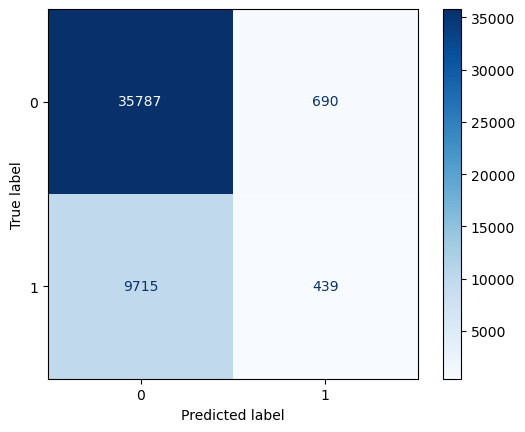

AUC:  0.622530342266611


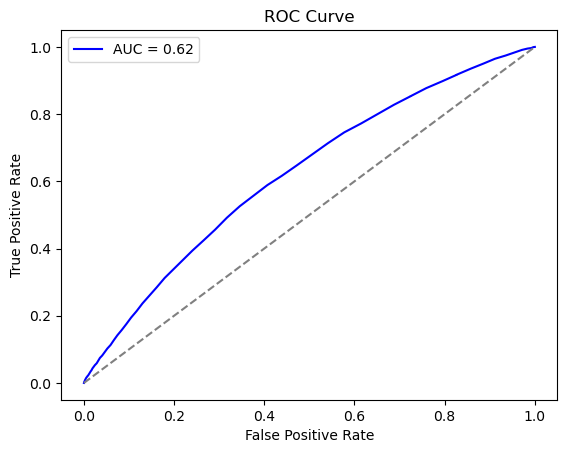

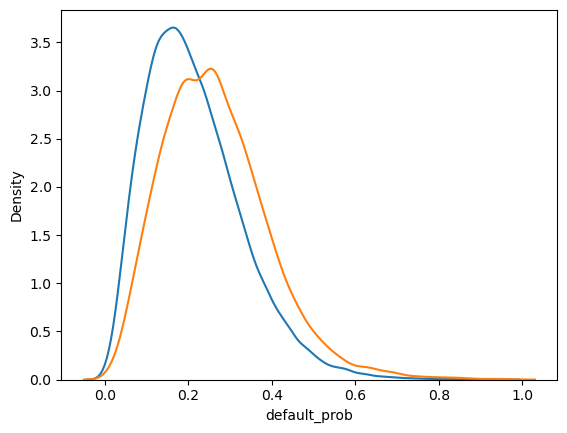

true_class  predicted_class
0           0                  0.981084
            1                  0.018916
1           0                  0.956766
            1                  0.043234
Name: proportion, dtype: float64


In [310]:
rfc_model = RandomForestClassifier()
rfc_model.fit(x_train, y_train)

eval_model(rfc_model, x_test, y_test)

## Hyperparameters 



Accuracy:  0.6709699556089297
Precision:  0.2545643742313878
Recall:  0.2650187118376994
F1:  0.259686369119421


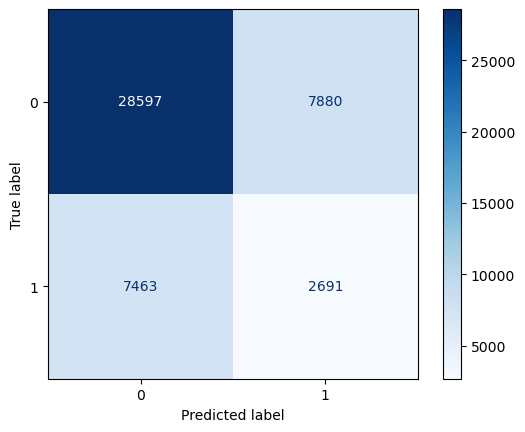

AUC:  0.524542197106469


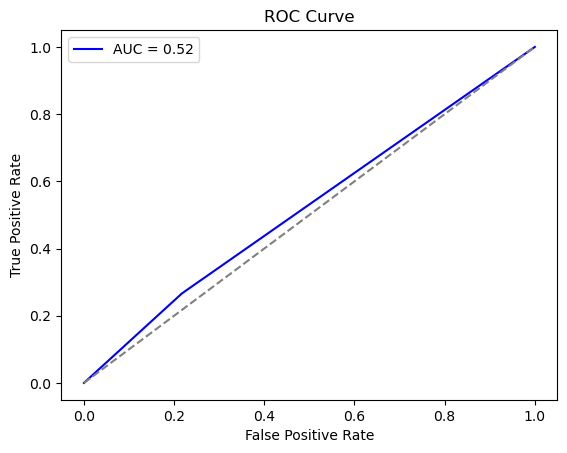

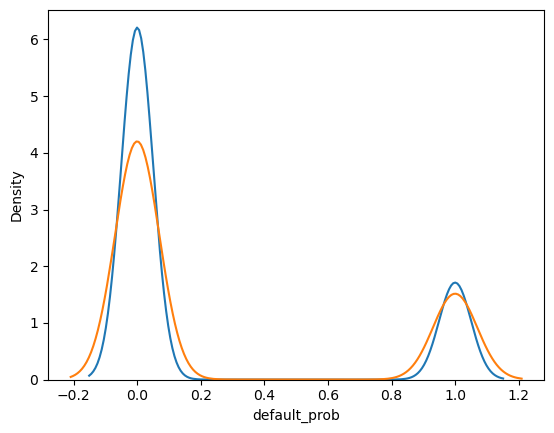

true_class  predicted_class
0           0                  0.783973
            1                  0.216027
1           0                  0.734981
            1                  0.265019
Name: proportion, dtype: float64


In [312]:
# estimators=1
rfc_model = RandomForestClassifier(n_estimators=1)
rfc_model.fit(x_train, y_train)

eval_model(rfc_model, x_test, y_test)



Accuracy:  0.7668503785035706
Precision:  0.33486660533578655
Recall:  0.07169588339570612
F1:  0.11810512654120699


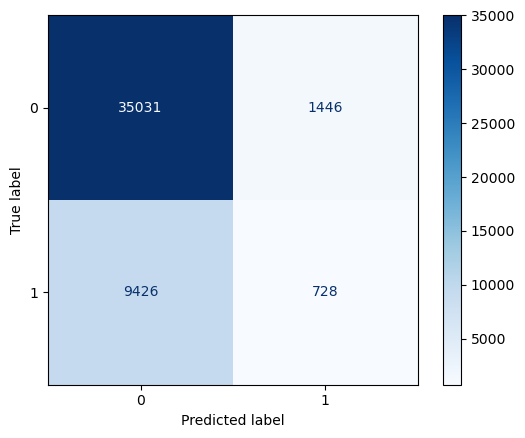

AUC:  0.5823427868337809


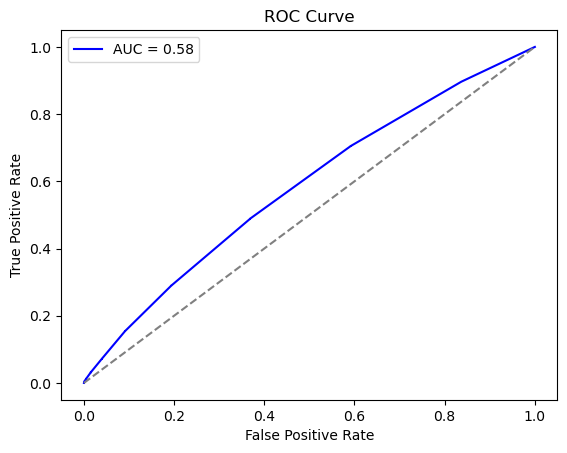

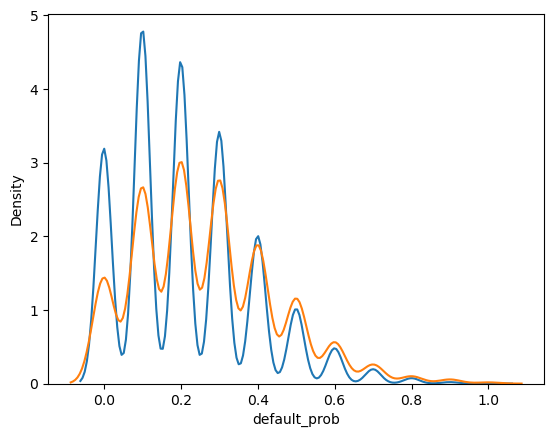

true_class  predicted_class
0           0                  0.960359
            1                  0.039641
1           0                  0.928304
            1                  0.071696
Name: proportion, dtype: float64


In [313]:
# estimators=10
rfc_model = RandomForestClassifier(n_estimators=10)
rfc_model.fit(x_train, y_train)

eval_model(rfc_model, x_test, y_test)

In [ ]:
# estimators=100
# rfc_model = RandomForestClassifier(n_estimators=100)
# rfc_model.fit(x_train, y_train)

# eval_model(rfc_model, x_test, y_test)

In [ ]:
# estimators=300
# rfc_model = RandomForestClassifier(n_estimators=300)
# rfc_model.fit(x_train, y_train)

# eval_model(rfc_model, x_test, y_test)

### Maximum Depth

In [317]:
# max_depth=5
# rfc_model = RandomForestClassifier(n_estimators=100, max_depth=5)
# rfc_model.fit(x_train, y_train)

# eval_model(rfc_model, x_test, y_test)

In [ ]:
# check the overfitting
# eval_model(rfc_model, x_train, y_train)

# Class Balancing

In [320]:
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample

## Weight Balancing 

### Random Forest 

- Just for fun let's build and train the random forest classifier with the parameters we found in chapter 7

### EXERCISE 

- Create training and test data for the full feature set 
- Use the tuned hyperparameters from the previous chapter to create a baseline Random Forest



Accuracy:  0.7830413244408226
Precision:  0.7176470588235294
Recall:  0.006007484735079772
F1:  0.011915226096298467


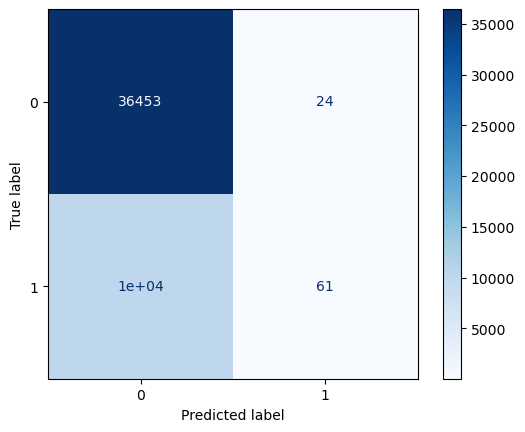

AUC:  0.6480591575538717


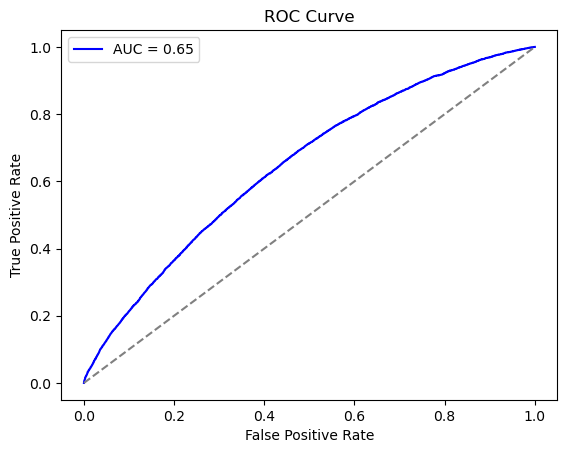

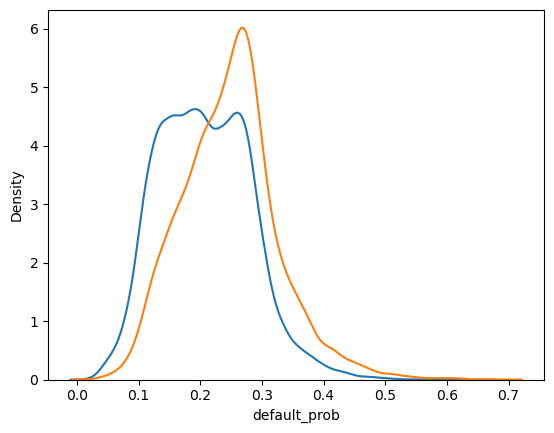

true_class  predicted_class
0           0                  0.999342
            1                  0.000658
1           0                  0.993993
            1                  0.006007
Name: proportion, dtype: float64


In [321]:
x_train, x_test, y_train, y_test = encode_and_split(loan_df)
rfc_model = RandomForestClassifier(n_estimators = 100, max_depth = 15)

rfc_model.fit(x_train, y_train)
eval_model(rfc_model, x_test, y_test)



Accuracy:  0.6338701722030409
Precision:  0.3031578947368421
Recall:  0.5247193224345086
F1:  0.38429081467056153


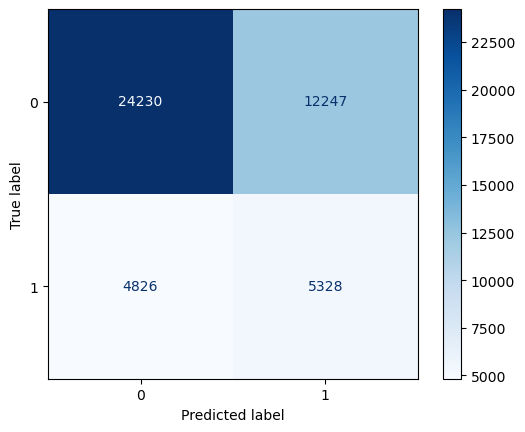

AUC:  0.6388341313652148


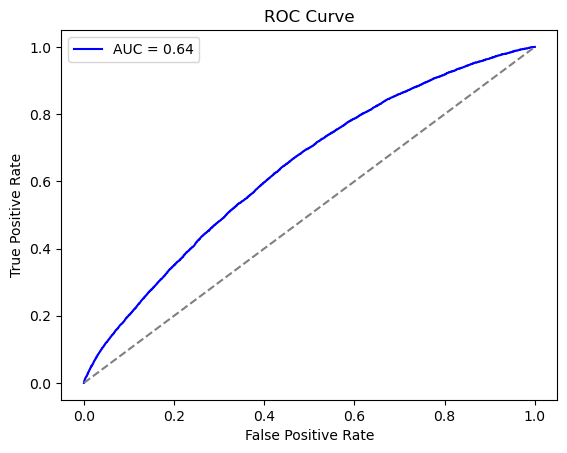

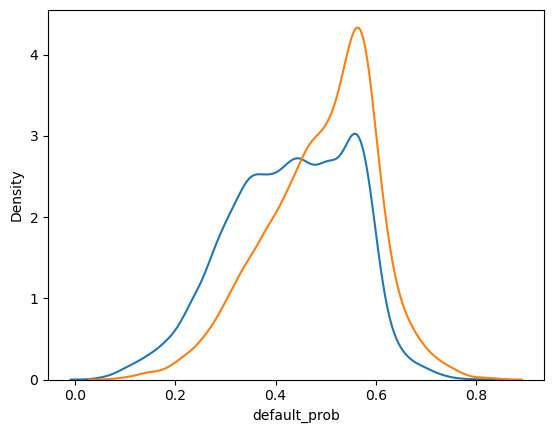

true_class  predicted_class
0           0                  0.664254
            1                  0.335746
1           1                  0.524719
            0                  0.475281
Name: proportion, dtype: float64


In [322]:
# balance rfc
rfc_model = RandomForestClassifier(n_estimators = 100, max_depth = 15, class_weight='balanced')

rfc_model.fit(x_train, y_train)
eval_model(rfc_model, x_test, y_test)

### Manual Class Weighting



Accuracy:  0.7295361454826189
Precision:  0.3450579929399899
Recall:  0.26954894622808745
F1:  0.30266504478602235


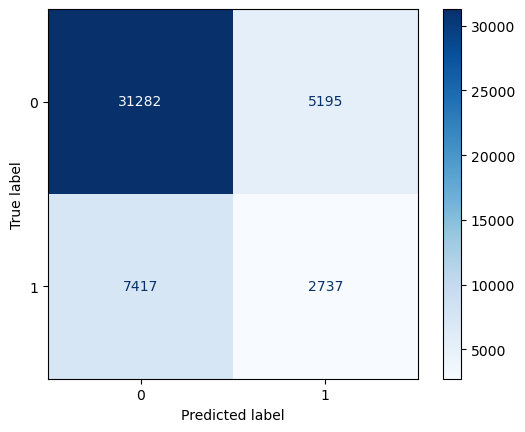

AUC:  0.6425215132419522


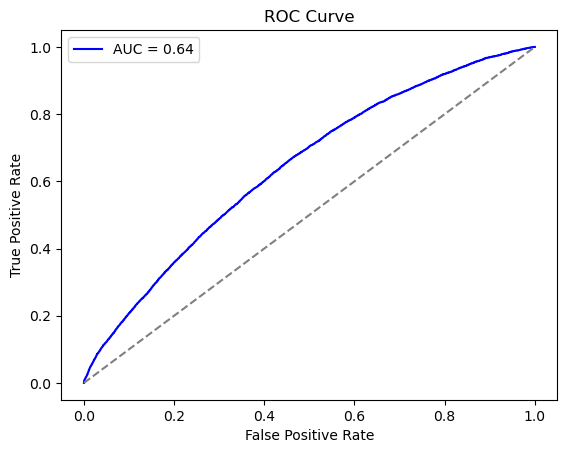

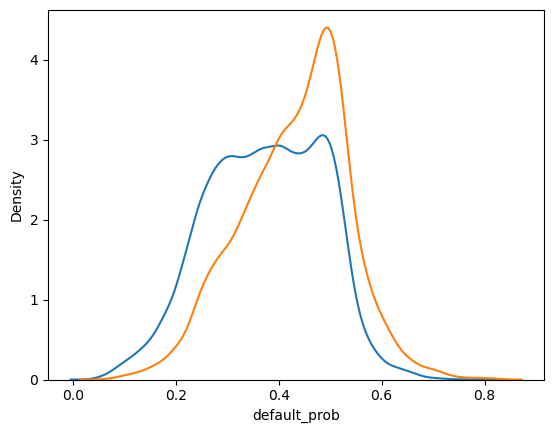

true_class  predicted_class
0           0                  0.857581
            1                  0.142419
1           0                  0.730451
            1                  0.269549
Name: proportion, dtype: float64


In [323]:
# Manual Weighting rfc
weights = {0:0.27, 1:0.73}

rfc_model = RandomForestClassifier(n_estimators = 100, max_depth = 15, class_weight=weights)

rfc_model.fit(x_train, y_train)
eval_model(rfc_model, x_test, y_test)

## Resampling


### Upsampling


In [324]:
# copy x_train
train_df = x_train.copy()
train_df['LOAN_DEFAULT'] = y_train

In [325]:
# check
print(train_df['LOAN_DEFAULT'].value_counts())
print(train_df['LOAN_DEFAULT'].value_counts(normalize=True))

LOAN_DEFAULT
0    146066
1     40457
Name: count, dtype: int64
LOAN_DEFAULT
0    0.783099
1    0.216901
Name: proportion, dtype: float64


In [326]:
# split by target classes
train_minority = train_df[train_df['LOAN_DEFAULT'] == 1]
train_majority = train_df[train_df['LOAN_DEFAULT'] == 0]

In [327]:
# Upsampling
train_minority_up = resample(train_minority, replace=True,  n_samples=train_majority.shape[0], random_state=123)

In [328]:
# check
print(train_majority['LOAN_DEFAULT'].value_counts())
print(train_minority_up['LOAN_DEFAULT'].value_counts())

LOAN_DEFAULT
0    146066
Name: count, dtype: int64
LOAN_DEFAULT
1    146066
Name: count, dtype: int64


In [330]:
# full training set
train_up_df = pd.concat([train_majority, train_minority_up])

In [331]:
# check
print(train_up_df['LOAN_DEFAULT'].value_counts())
print(train_up_df['LOAN_DEFAULT'].value_counts(normalize=True))

LOAN_DEFAULT
0    146066
1    146066
Name: count, dtype: int64
LOAN_DEFAULT
0    0.5
1    0.5
Name: proportion, dtype: float64


In [332]:
# split
x_train_up = train_up_df.drop(['LOAN_DEFAULT'], axis=1)
y_train_up = train_up_df['LOAN_DEFAULT']



Accuracy:  0.622354227874161
Precision:  0.3028139215064001
Recall:  0.5638172148906835
F1:  0.39401238816242257


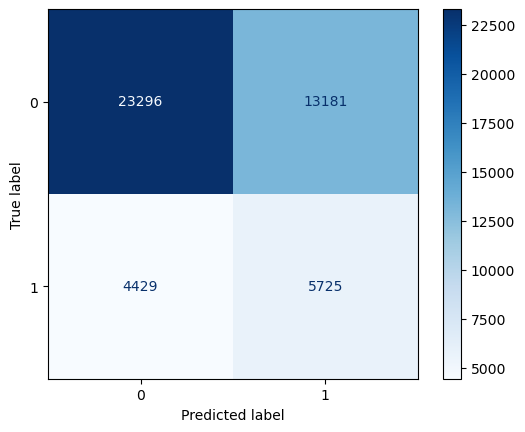

AUC:  0.642870846074923


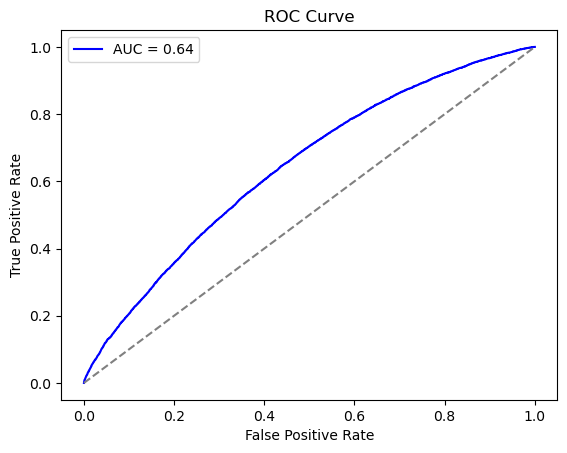

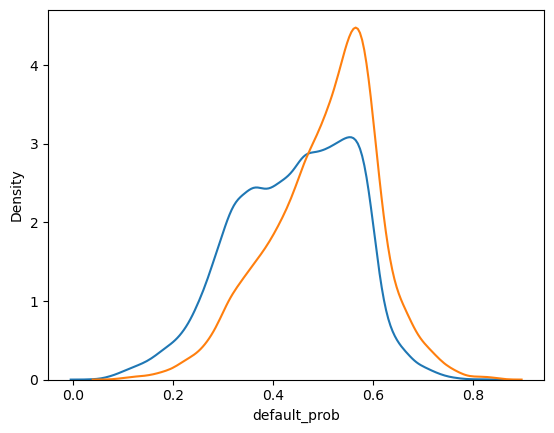

true_class  predicted_class
0           0                  0.638649
            1                  0.361351
1           1                  0.563817
            0                  0.436183
Name: proportion, dtype: float64


In [333]:
# eval
rfc_model = RandomForestClassifier(n_estimators = 100, max_depth=15)

rfc_model.fit(x_train_up, y_train_up)
eval_model(rfc_model, x_test, y_test)

### Downsampling

In [335]:
def balance_sample(x_train, y_train, sample_mode='up'):
    train_df = x_train.copy()
    train_df['LOAN_DEFAULT'] = y_train

    train_minority = train_df[train_df['LOAN_DEFAULT'] == 1]
    train_majority = train_df[train_df['LOAN_DEFAULT'] == 0]

    train_sampled_df = pd.DataFrame()

    if sample_mode == 'down':
        train_majority_down = resample(train_majority, replace=False,  n_samples=train_minority.shape[0], random_state=123)
        train_sampled_df = pd.concat([train_minority, train_majority_down])  
    else:
        train_minority_up = resample(train_minority, replace=True,  n_samples=train_majority.shape[0], random_state=123)
        train_sampled_df = pd.concat([train_majority, train_minority_up])

    x_train_samp = train_sampled_df.drop(['LOAN_DEFAULT'], axis=1)
    y_train_samp = train_sampled_df['LOAN_DEFAULT']

    return x_train_samp, y_train_samp 

### EXERCISE

- Use the balance_sample function to create downsampled training data

In [336]:
x_train_dwn, y_train_dwn = balance_sample(x_train, y_train, sample_mode='down')

print(y_train_dwn.value_counts())
print(y_train_dwn.value_counts(normalize=True))

LOAN_DEFAULT
1    40457
0    40457
Name: count, dtype: int64
LOAN_DEFAULT
1    0.5
0    0.5
Name: proportion, dtype: float64




Accuracy:  0.582037700242328
Precision:  0.2920712694877506
Recall:  0.645755367342919
F1:  0.4022205864311128


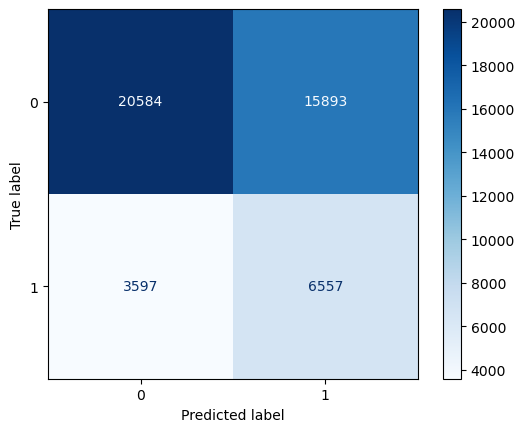

AUC:  0.6467337671028807


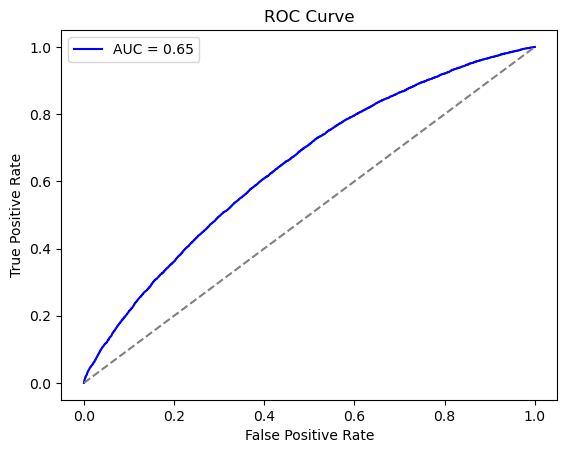

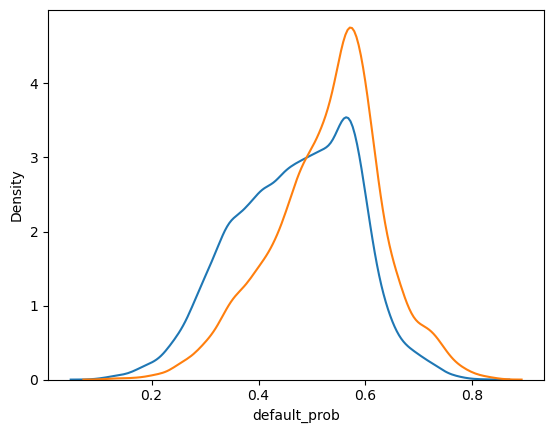

true_class  predicted_class
0           0                  0.564301
            1                  0.435699
1           1                  0.645755
            0                  0.354245
Name: proportion, dtype: float64


In [337]:
# train model
rfc_model = RandomForestClassifier(n_estimators = 100, max_depth = 15)

rfc_model.fit(x_train_dwn, y_train_dwn)
eval_model(rfc_model, x_test, y_test)

### SMOTE

In [338]:
smote = SMOTE()

In [339]:
# training data
x_train_synth, y_train_synth = smote.fit_resample(x_train, y_train)

In [340]:
# check the class distribution
print(y_train_synth.value_counts())
print(y_train_synth.value_counts(normalize=True))

LOAN_DEFAULT
1    146066
0    146066
Name: count, dtype: int64
LOAN_DEFAULT
1    0.5
0    0.5
Name: proportion, dtype: float64




Accuracy:  0.6580386438206344
Precision:  0.29933481152993346
Recall:  0.4254480992712232
F1:  0.3514195070365248


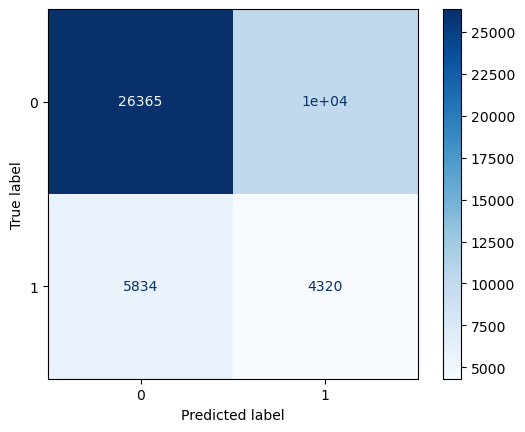

AUC:  0.6229833179178546


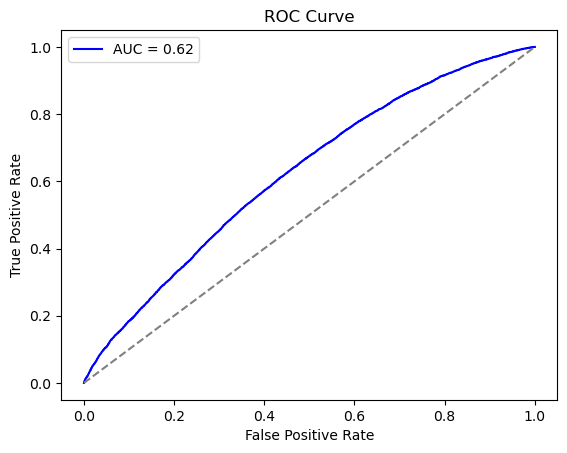

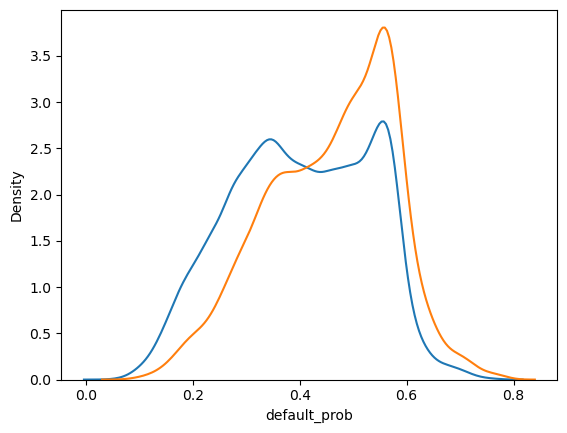

true_class  predicted_class
0           0                  0.722784
            1                  0.277216
1           0                  0.574552
            1                  0.425448
Name: proportion, dtype: float64


In [341]:
# train model
rfc_model = RandomForestClassifier(n_estimators = 100, max_depth = 15)

rfc_model.fit(x_train_synth, y_train_synth)
eval_model(rfc_model, x_test, y_test)